In [1]:
import pandas as pd
#import numpy as np

links = pd.read_csv('ml-latest/links.csv')
movies = pd.read_csv('ml-latest/movies.csv')
ratings = pd.read_csv('ml-latest/ratings.csv')
tags = pd.read_csv('ml-latest/tags.csv')

## EDA

### initial look at the data sets

---

it seems that links don't include any overly relevant information, from the labb pm: "The file link.csv contains cross-references between different movie sites and
requires more advanced techniques to utilize. If you are building a Dash appli
cation, it might be worth including the links."

In [2]:
links.describe()

,movieId,imdbId,tmdbId
count,86537.000000,8.653700e+04,8.641100e+04
mean,155932.817096,2.696384e+06,2.363101e+05
std,78037.145347,4.078415e+06,2.404829e+05
min,1.000000,1.000000e+00,2.000000e+00
25%,111443.000000,9.381100e+04,4.632800e+04
50%,164574.000000,4.845620e+05,1.362170e+05
75%,211225.000000,3.775202e+06,3.762850e+05
max,288983.000000,2.822749e+07,1.147612e+06


In [3]:
links.columns

Index(['movieId', 'imdbId', 'tmdbId'], dtype='str')

---

it seems movies is a list of all the movies, their id's and their genres.

In [4]:
movies.describe()

,movieId
count,86537.000000
mean,155932.817096
std,78037.145347
min,1.000000
25%,111443.000000
50%,164574.000000
75%,211225.000000
max,288983.000000


In [5]:
movies.columns

Index(['movieId', 'title', 'genres'], dtype='str')

---

ratings seems like the most relevant data set, at first glance it looks like it contains info (user, movie, rating, timestamp) about reviews

In [6]:
ratings.describe()

,userId,movieId,rating,timestamp
count,3.383216e+07,3.383216e+07,3.383216e+07,3.383216e+07
mean,1.654380e+05,2.831348e+04,3.542540e+00,1.269362e+09
std,9.534122e+04,4.992865e+04,1.063959e+00,2.541023e+08
min,1.000000e+00,1.000000e+00,5.000000e-01,7.896520e+08
25%,8.295300e+04,1.219000e+03,3.000000e+00,1.046718e+09
50%,1.661290e+05,3.263000e+03,4.000000e+00,1.264740e+09
75%,2.474500e+05,4.049100e+04,4.000000e+00,1.496919e+09
max,3.309750e+05,2.889830e+05,5.000000e+00,1.689843e+09


In [7]:
ratings.columns

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='str')

---

the categorical data in tags might be very useful, I can't know that yet though

In [8]:
tags.describe()

,userId,movieId,timestamp
count,2.328315e+06,2.328315e+06,2.328315e+06
mean,1.776665e+05,7.055280e+04,1.522919e+09
std,8.285669e+04,7.402427e+04,1.308546e+08
min,1.000000e+01,1.000000e+00,1.135429e+09
25%,1.144050e+05,3.897000e+03,1.457997e+09
50%,2.154900e+05,5.107700e+04,1.561826e+09
75%,2.154900e+05,1.175330e+05,1.614286e+09
max,3.309470e+05,2.889550e+05,1.689841e+09


In [9]:
tags.columns

Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='str')

### in depth look at movies

---
The genres columns seems extreamely cluttered but it seems all entries in the column follow the same format which would make separating (and possibly one-hot encoding) the genres easy

In [10]:
movies['genres'].unique()

<StringArray>
[          'Adventure|Animation|Children|Comedy|Fantasy',
                            'Adventure|Children|Fantasy',
                                        'Comedy|Romance',
                                  'Comedy|Drama|Romance',
                                                'Comedy',
                                 'Action|Crime|Thriller',
                                    'Adventure|Children',
                                                'Action',
                             'Action|Adventure|Thriller',
                                         'Comedy|Horror',
 ...
                'Action|Animation|Comedy|Romance|Sci-Fi',
                       'Action|Animation|Romance|Sci-Fi',
                        'Animation|Children|Documentary',
                      'Crime|Documentary|Drama|Thriller',
             'Adventure|Fantasy|Horror|Mystery|Thriller',
 'Action|Adventure|Drama|Fantasy|Mystery|Romance|Sci-Fi',
                    'Adventure|Animation|Comedy|Weste

In [11]:
movies.info()

<class 'pandas.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   movieId  86537 non-null  int64
 1   title    86537 non-null  str  
 2   genres   86537 non-null  str  
dtypes: int64(1), str(2)
memory usage: 2.0 MB


encoded movies

In [12]:
movies = pd.read_csv('ml-latest/movies_encoded.csv')

movies.head(3)

,Unnamed: 0,movieId,title,genres,(no genres listed),Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,0,1,Toy Story (1995),"['Adventure', 'Animation', 'Children', 'Comedy...",0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,1,2,Jumanji (1995),"['Adventure', 'Children', 'Fantasy']",0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2,3,Grumpier Old Men (1995),"['Comedy', 'Romance']",0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0


### in depth look at ratings

---
It seems all ratings are between 0.5 and 5.

In [13]:
ratings['rating'].unique()

array([4. , 4.5, 5. , 3.5, 3. , 2. , 2.5, 1. , 1.5, 0.5])

Ratings contain both userID and movieID, this means that it would be easy to combine it with other data sets.

In [14]:
ratings.info()

<class 'pandas.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 1.0 GB


<Axes: >

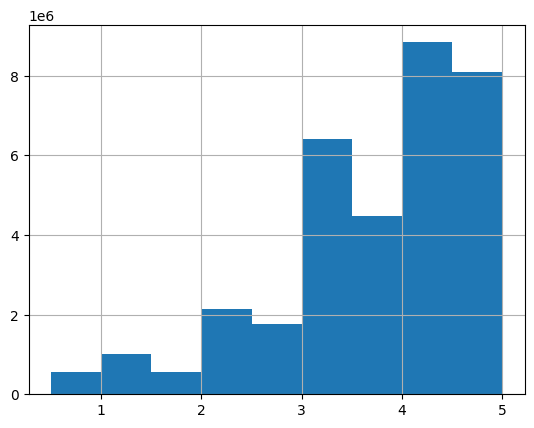

In [15]:
ratings['rating'].hist(bins=9)

### in depth look at tags

---
tags seems easy to include in a bigger dataset

In [16]:
tags.info()

<class 'pandas.DataFrame'>
RangeIndex: 2328315 entries, 0 to 2328314
Data columns (total 4 columns):
 #   Column     Dtype
---  ------     -----
 0   userId     int64
 1   movieId    int64
 2   tag        str  
 3   timestamp  int64
dtypes: int64(3), str(1)
memory usage: 71.1 MB


the column "tag" contains commonon themes for movies

In [17]:
tags['tag'].unique()

<StringArray>
[        'good vs evil',        'Harrison Ford',               'sci-fi',
            'Al Pacino',                'mafia',          'Atmospheric',
               'Batman',           'comic book',                 'dark',
         'Heath Ledger',
 ...
   'Satoshi Urushihara',    'Annoying Sidekick',         'under played',
       'Primal revenge',       'bad guy motive',           'soft-edged',
 'visually captivating',    'jimcarrey-on fire',     'young jim carrey',
    'political correct']
Length: 153950, dtype: str

I have no idea what timestamp is.

In [18]:
tags['timestamp'].unique()

array([1430666558, 1430666505, 1430666538, ..., 1351279389, 1154110902,
       1154271525], shape=(1607772,))

### more exploration
---

In [19]:
movies.loc[movies['movieId'].isin(list(ratings.loc[ratings['userId'] == 999, 'movieId'])), 'title']

536                                    Blade Runner (1982)
734      Dr. Strangelove or: How I Learned to Stop Worr...
1166     Star Wars: Episode V - The Empire Strikes Back...
1170                                         Aliens (1986)
1177                                 Apocalypse Now (1979)
1179     Star Wars: Episode VI - Return of the Jedi (1983)
1183                                          Alien (1979)
1241                                          Akira (1988)
1666                              Big Lebowski, The (1998)
2480                                    Matrix, The (1999)
2537      Star Wars: Episode I - The Phantom Menace (1999)
3063                               Bicentennial Man (1999)
3207                                    Pitch Black (2000)
3924                     O Brother, Where Art Thou? (2000)
4773                                   Donnie Darko (2001)
4868     Amelie (Fabuleux destin d'Amélie Poulain, Le) ...
5509     Spirited Away (Sen to Chihiro no kamikakushi) .

quick check if movies have been rated by a user

In [20]:
movie_id = 117529
user = 999

movie_id in ratings.loc[ratings['userId'] == user, 'movieId'].values

False

<Axes: >

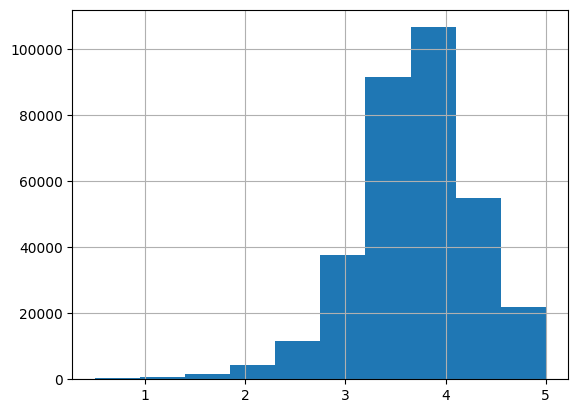

In [21]:
ratings['avg_rating'] = ratings.groupby('userId').mean()['rating']
ratings['avg_rating'].hist()